In [1]:
3+3

6

In [2]:
import os
from dotenv import load_dotenv
import langchain
import langchain_core
from langchain_tavily import TavilySearch
from langchain.chat_models import init_chat_model

In [3]:
tool = TavilySearch(max_results=2)


In [4]:
def multiply(a:int,b:int) -> int:
    """Muntiply a and b"""
    return a*b

In [5]:
tools = [tool,multiply]

In [6]:
llm = init_chat_model("groq:llama-3.1-8b-instant")

In [7]:
llm_with_tools = llm.bind_tools(tools)

In [8]:
# shared memory || shared state
from typing import Annotated, TypedDict

from langgraph.graph import add_messages

class State(TypedDict):
    messages : Annotated[list,add_messages]

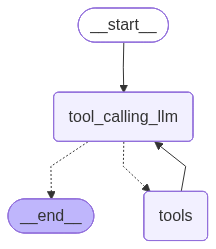

In [9]:
## Node Creation
from langgraph.graph import START, StateGraph
from langgraph.prebuilt import ToolNode, tools_condition
from IPython.display import Image,display


def tool_calling_llm(state:State):
    return{
        "messages":[llm_with_tools.invoke(state["messages"])]
    }

## graph
builder = StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))


# Add Edges
builder.add_edge(START,"tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",tools_condition
)
builder.add_edge("tools","tool_calling_llm")
# complile the graph
graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))




In [10]:
graph.invoke({"messages":["what is recent ai news"]})

{'messages': [HumanMessage(content='what is recent ai news', additional_kwargs={}, response_metadata={}, id='ee4edc63-37c0-49a8-998c-0197788e90ce'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'h0td6k00s', 'function': {'arguments': '{"query":"recent ai news","search_depth":"advanced","topic":"news"}', 'name': 'tavily_search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 31, 'prompt_tokens': 1746, 'total_tokens': 1777, 'completion_time': 0.042059266, 'completion_tokens_details': None, 'prompt_time': 0.114558511, 'prompt_tokens_details': None, 'queue_time': 0.058438428, 'total_time': 0.156617777}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e4b6a-2181-7102-8ff0-346a7c78d4a5-0', tool_calls=[{'name': 'tavily_search', 'args': {'query': 'recent ai news', 'search_depth': 'advanced', 'top

In [11]:
responce = graph.invoke({"messages":["what is recent ai news and 5 multiply 5"]})

In [12]:
for m in responce["messages"]:
    m.pretty_print()
    

================================ Human Message =================================

what is recent ai news and 5 multiply 5
================================== Ai Message ==================================
Tool Calls:
  tavily_search (yzgvfgcqj)
 Call ID: yzgvfgcqj
  Args:
    query: recent AI news
    time_range: day
    topic: news
  multiply (85905y98t)
 Call ID: 85905y98t
  Args:
    a: 5
    b: 5
================================= Tool Message =================================
Name: tavily_search

{"query": "recent AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.axios.com/2026/05/21/ai-news-cycle-openai-anthropic-spacex", "title": "Two hours that changed AI - Axios", "score": 0.7880784, "published_date": "Thu, 21 May 2026 09:20:05 GMT", "content": "# Two hours that changed AI. Over the course of two hours Wednesday afternoon, the AI industry produced an extraordinary stream of headlines mapping out the vast architecture of its ambi

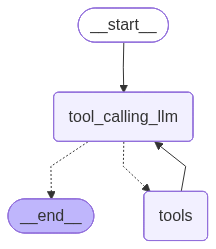

In [13]:

from langgraph.graph import START, StateGraph
from langgraph.prebuilt import ToolNode, tools_condition
from IPython.display import Image,display
from langgraph.checkpoint.memory import MemorySaver
from IPython.display import Image,display

memory = MemorySaver()
# # Node Creation || node defination
def tool_calling_llm(state:State):
    return{
        "messages":[llm_with_tools.invoke(state["messages"])]
    }

## graph
builder = StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))


# Add Edges
builder.add_edge(START,"tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",tools_condition
)
builder.add_edge("tools","tool_calling_llm")
# complile the graph
graph = builder.compile(checkpointer=memory)

display(Image(graph.get_graph().draw_mermaid_png()))

In [14]:
from langchain_core.runnables import RunnableConfig
config: RunnableConfig = {
    "configurable": {
        "thread_id": "1"
    }
}
responce = graph.invoke(
    {
        "messages":[("Hi My Name is Mohit")]
    },config=config
)

In [15]:
responce

{'messages': [HumanMessage(content='Hi My Name is Mohit', additional_kwargs={}, response_metadata={}, id='e8ef7f4b-1f26-435d-9673-28ff4e8b3215'),
  AIMessage(content="It's nice to meet you Mohit. Is there anything I can help you with or would you like to chat?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 25, 'prompt_tokens': 1747, 'total_tokens': 1772, 'completion_time': 0.038261478, 'completion_tokens_details': None, 'prompt_time': 0.116991604, 'prompt_tokens_details': None, 'queue_time': 0.056653165, 'total_time': 0.155253082}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e4b6a-9188-7bd3-a24a-911874c6efde-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 1747, 'output_tokens': 25, 'total_tokens': 1772})]}

In [16]:
responce['messages'][-1].content

"It's nice to meet you Mohit. Is there anything I can help you with or would you like to chat?"

In [ ]:
responce

{'messages': [HumanMessage(content='Hi My Name is Mohit', additional_kwargs={}, response_metadata={}, id='87daca2a-e38f-4ae5-8f3f-751103b30c39'),
  AIMessage(content="It's nice to meet you, Mohit. Is there something I can help you with or would you like to chat?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 26, 'prompt_tokens': 1747, 'total_tokens': 1773, 'completion_time': 0.042961461, 'completion_tokens_details': None, 'prompt_time': 0.119377872, 'prompt_tokens_details': None, 'queue_time': 0.061343697, 'total_time': 0.162339333}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e4b56-a146-7173-9756-cd48b3c93e62-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 1747, 'output_tokens': 26, 'total_tokens': 1773}),
  HumanMessage(content='what is my Name', additional_kwargs={}, response_meta

In [19]:
from langchain_core.messages import SystemMessage

# Insert a system message before your user message
response = graph.invoke(
    {
        "messages": [
            SystemMessage(content="You are a helpful assistant. Answer questions about the user based ONLY on the conversation history. Do not use search tools to look up the user's name."),
            ("user", "what is my Name")
        ]
    }, config=config
)

In [21]:
print(response['messages'][-1].content)

Your name is Mohit.


## Streaming

In [ ]:
## 